In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('nyc-rolling-sales.csv')
### Step 1: Data Overview:
# The Dataset contains NYC property sales records. I need to check for missing values, duplicates and data types before proceeding with the analysis.

df.head()
df.info()
# Check For Missing Values
df.isnull().sum()

### Interpretation:
# All 22 columns have 0 missing values. This means the dataset is complete and i can directly proceed to checking for duplicates and data types. No data cleaning is needed for missing values.

In [6]:
### Step 2: Check For Duplicate Rows:
# Now I'll check if there are any duplicate rows in the dataset. Duplicates can distort analysis by giving more weight to certain records.

# Count duplicate rows
df.duplicated().sum()

np.int64(0)

### Interpretation:
# There are 0 duplicate rows. Each record is unique and I can proceed with the data as-is.

In [7]:
### Step 3: Check Data Types
# Next, I'll check the data types of each column to ensure they are correct. For example, 'SALE PRICE' should be a number (int or float), and 'SALE DATE' should be a date (datetime).

# Check data types of each column
df.dtypes

Unnamed: 0                         int64
BOROUGH                            int64
NEIGHBORHOOD                      object
BUILDING CLASS CATEGORY           object
TAX CLASS AT PRESENT              object
BLOCK                              int64
LOT                                int64
EASE-MENT                         object
BUILDING CLASS AT PRESENT         object
ADDRESS                           object
APARTMENT NUMBER                  object
ZIP CODE                           int64
RESIDENTIAL UNITS                  int64
COMMERCIAL UNITS                   int64
TOTAL UNITS                        int64
LAND SQUARE FEET                  object
GROSS SQUARE FEET                 object
YEAR BUILT                         int64
TAX CLASS AT TIME OF SALE          int64
BUILDING CLASS AT TIME OF SALE    object
SALE PRICE                        object
SALE DATE                         object
dtype: object

### Interpretation:
# I notice a few issues that need to be fixed:

1. **'SALE PRICE'** is listed as **'object',** but it should be a number. This means it's currently stored as text and needs to be converted to a numeric type.

2. **'SALE DATE'** is **'object',** but it should be a **'datetime'** type so I can analyze sales over time.

3. **'LAND SQUARE FEET'**, and **'GROSS SQUARE FEET'** are also **'object'** but should be numeric so I can perform calculations on property size.

I will need to fix these data types in the next step.

### Step 4: Fix Data Types:

Now I will convert the problematic columns to their correct data types:

1. **'SALE PRICE'** to numeric (float)
2. **'LAND SQUARE FEET'** to numeric (float)
3. **'GROSS SQUARE FEET'** to numeric (float)
4. **'SALE DATE'** to datetime

In [21]:
# Remove commas and convert SALE PRICE to numeric
df['SALE PRICE'] = pd.to_numeric(df['SALE PRICE'], errors='coerce')

# Convert LAND SQUARE FEET to numeric
df['LAND SQUARE FEET'] = pd.to_numeric(df['LAND SQUARE FEET'], errors='coerce')

# Convert GROSS SQUARE FEET to numeric
df['GROSS SQUARE FEET'] = pd.to_numeric(df['GROSS SQUARE FEET'], errors='coerce')

# Convert SALE DATE to datetime
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

#Verify the changes
df.dtypes

Unnamed: 0                                 int64
BOROUGH                                    int64
NEIGHBORHOOD                              object
BUILDING CLASS CATEGORY                   object
TAX CLASS AT PRESENT                      object
BLOCK                                      int64
LOT                                        int64
EASE-MENT                                 object
BUILDING CLASS AT PRESENT                 object
ADDRESS                                   object
APARTMENT NUMBER                          object
ZIP CODE                                   int64
RESIDENTIAL UNITS                          int64
COMMERCIAL UNITS                           int64
TOTAL UNITS                                int64
LAND SQUARE FEET                         float64
GROSS SQUARE FEET                        float64
YEAR BUILT                                 int64
TAX CLASS AT TIME OF SALE                  int64
BUILDING CLASS AT TIME OF SALE            object
SALE PRICE          

### Interpretation

After converting the columns:

- **'SALE PRICE'** is now **float64** - any values that couldn't be converted like (**'-'**) became **'NaN'**
- **'LAND SQUARE FEET'** is now **'float64'**
- **'GROSS SQUARE FEET'** is now **'float64'**
- **'SALE DATE'** is now **'datetime64[ns]'**

I'll need to check how many rows became **'NaN'** and decide whether to drop them or fill them with appropriate values.

In [24]:
# Check new missing values after conversion
print("New missing values per column:")
df.isnull().sum()

New missing values per column:


Unnamed: 0                            0
BOROUGH                               0
NEIGHBORHOOD                          0
BUILDING CLASS CATEGORY               0
TAX CLASS AT PRESENT                  0
BLOCK                                 0
LOT                                   0
EASE-MENT                             0
BUILDING CLASS AT PRESENT             0
ADDRESS                               0
APARTMENT NUMBER                      0
ZIP CODE                              0
RESIDENTIAL UNITS                     0
COMMERCIAL UNITS                      0
TOTAL UNITS                           0
LAND SQUARE FEET                  26252
GROSS SQUARE FEET                 27612
YEAR BUILT                            0
TAX CLASS AT TIME OF SALE             0
BUILDING CLASS AT TIME OF SALE        0
SALE PRICE                        14561
SALE DATE                             0
dtype: int64

In [25]:
# Check total number of rows
total_rows = len(df)
print("Total rows in dataset:", total_rows)

Total rows in dataset: 84548


In [28]:
# Total rows
total_rows = 84548

# Calculate percentages
land_percent = (26252 / total_rows) * 100
gross_percent = (27612 / total_rows) * 100
price_percent = (14561 / total_rows) * 100

print(f"Total rows: {total_rows}")
print("-" * 30)
print(f"LAND SQUARE FEET missing: {land_percent:.1f}%")
print(f"GROSS SQUARE FEET missing: {gross_percent:.1f}%")
print(f"SALE PRICE missing: {price_percent:.1f}%")

Total rows: 84548
------------------------------
LAND SQUARE FEET missing: 31.0%
GROSS SQUARE FEET missing: 32.7%
SALE PRICE missing: 17.2%


### Step 5: Handle Missing Values:

After converting columns to numeric types, some values became **NaN**. Here's what I found out:

| **Column** | **Missing Count** | **Percentage** |
| :--- | :--- | :--- |
| LAND SQUARE FEET | 26,252 | 31.0% |
| GROSS SQUARE FEET | 27,612 | 32.7 % |
| SALE PRICE | 14,561 | 17.2% |

**Handling Strategy:**
1. **SALE PRICE (17.2% Missing):** Drop these rows because this is the target variable for analysis
2. **LAND SQUARE FEET (31.0% Missing):** Fill with median because dropping would lose too much data
3. **GROSS SQUARE FEET (32.7% Missing):** Fill with median because dropping would lose too much data

I used **'.copy()'** to avoid the **'SettingWithCopyWarning'** and ensure safe data manipulation.

In [30]:
# Handle missing values

# Step 1: Drop rows where SALE PRICE is missing (essential column)
df_clean = df.dropna(subset=['SALE PRICE']).copy()
print(f"Rows after dropping missing SALE PRICE: {len(df_clean)}")

# Step 2: Fill LAND SQUARE FEET with median
df_clean['LAND SQUARE FEET'] = df_clean['LAND SQUARE FEET'].fillna(df_clean['LAND SQUARE FEET'].median())

# Step 3: Fill GROSS SQUARE FEET with median
df_clean['GROSS SQUARE FEET'] = df_clean['GROSS SQUARE FEET'].fillna(df_clean['GROSS SQUARE FEET'].median())

# Step 4: Verify no missing values remain in these columns
print("\nMissing values after handling:")
print(df_clean[['SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET']].isnull().sum())

# Step 5: Check new dataset
print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Rows dropped: {df.shape[0] - df_clean.shape[0]}")   

Rows after dropping missing SALE PRICE: 69987

Missing values after handling:
SALE PRICE           0
LAND SQUARE FEET     0
GROSS SQUARE FEET    0
dtype: int64

Final dataset shape: (69987, 22)
Rows dropped: 14561


### Results

After handling missing values:

- **Rows dropped (Missing SALE PRICE):** 14,561
- **Rows remaining:** 69,987
- **Final dataset shape:** (69,987, 22)

**Verification:** No missing values remain in **'SALE PRICE'**, **'LAND SQUARE FEET'**, **'GROSS SQUARE FEET'**.

The dataset is now ready for exploratory data analysis.

In [31]:
# Summary statistics for numeric columns
df_clean.describe()

,Unnamed: 0,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
count,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,69987.000000,6.998700e+04,6.998700e+04,69987.000000,69987.000000,6.998700e+04,69987
mean,10287.503822,2.921928,4196.072528,373.828397,10741.455185,1.899553,0.172489,2.092203,3.181520e+03,3.034999e+03,1799.348236,1.641976,1.276456e+06,2017-02-27 21:22:54.478117376
min,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00,2016-09-01 00:00:00
25%,4182.000000,2.000000,1348.000000,22.000000,10306.000000,0.000000,0.000000,0.000000,1.900000e+03,1.268000e+03,1920.000000,1.000000,2.250000e+05,2016-11-30 00:00:00
50%,8989.000000,3.000000,3378.000000,50.000000,11209.000000,1.000000,0.000000,1.000000,2.150000e+03,1.620000e+03,1937.000000,2.000000,5.300000e+05,2017-02-28 00:00:00
75%,15874.000000,4.000000,6186.000000,709.000000,11249.000000,2.000000,0.000000,2.000000,2.504000e+03,2.068000e+03,1965.000000,2.000000,9.500000e+05,2017-05-31 00:00:00
max,26738.000000,5.000000,16319.000000,9106.000000,11694.000000,1844.000000,2261.000000,2261.000000,4.252327e+06,3.750565e+06,2017.000000,4.000000,2.210000e+09,2017-08-31 00:00:00
std,7098.651334,1.235688,3429.196524,656.096528,1263.234938,14.549545,9.123717,17.276100,3.370635e+04,2.449154e+04,520.884552,0.771162,1.140526e+07,NaN


### Step 6: Summary Statistics:

After cleaning the data, I calculated the summary statistics for all numeric columns.

**Key Observations:**

| **Statistic** | **Value** |
| :--- | :--- |
| Total Properties | 69,987 |
| Average Sale Price | $1,276,456 |
| Median Sale Price | $530,000 |
| Minimum Sale Price | $0 |
| Maximum Sale Price | $2,210,000,000|
| Average Year Built | 1799 (skewed by entries with 0) |
| Median Year Built | 1937 |

**Insights:**

1. **Price Distribution is Skewed:** The median is $530k but the mean is $1,27M, indicating a few very expensive properties pulling the average up.

2. **Outliers Exist:** The maximum sale price is $2,21B and minimum is $0. These may represent unusual transactions (commercial buildings, gifts, transfers) that I should investigate further.

3. **Most Properties are Small:** The median property has 1 residential unit and 1 total unit, suggesting most sales are single-family homes or individual condos.

4. **Year Built Anomaly:** The minimum YEAR BUILT is 0, which indicates missing data that wasnt captured. I should consider filtering out properties with YEAR BUILT = 0. 

### Step 7: Investigate Outliers:

After reviewing the summary statistics, I noticed several potential outliers that could affect my analysis:

1. **Properties with $0 sale price** - These may represent gifts, transfers or errors.
2. **Properties with YEAR BUILT = 0** - Missing or unknown construction year.
3. **Extremely high sale prices** - Properties selling for billions dollars

I will investigate each of these to understand their impact and decide how to handle them.

In [32]:
# Check properties with SALE PRICE = 0
zero_price = df_clean[df_clean['SALE PRICE'] == 0]
print(f"Properties with $0 sale price: {len(zero_price)}")
print(zero_price[['SALE PRICE', 'BOROUGH', 'BUILDING CLASS CATEGORY']].head())

Properties with $0 sale price: 10228
       SALE PRICE  BOROUGH                      BUILDING CLASS CATEGORY
18311         0.0        2  01 ONE FAMILY DWELLINGS                    
18313         0.0        2  01 ONE FAMILY DWELLINGS                    
18314         0.0        2  02 TWO FAMILY DWELLINGS                    
18315         0.0        2  02 TWO FAMILY DWELLINGS                    
18320         0.0        2  02 TWO FAMILY DWELLINGS                    


### Analysis: Properties with $0 Sale Price

**Findings:**
- **10,228 properties** have a sale price of $0 (14% of the dataset)
- All of these are in **Borough 2 (Bronx)**
- Most are **single-family** or **two-family dwellings**

**Interpretation:**

Properties with a $0 sale price likely represent:
- Gift transfers (family members)
- Inheritance transfers
- Data entry errors
- Non-market transactions

These transactions are not true market sales and would distort any analysis of market prices.

**Decision:**
I will drop all rows with **'SALE PRICE = 0'** because:
1. They do not represent actual market transactions.
2. They would artificially lower the average sale price.
3. They are not useful for predicting market prices. 

In [33]:
# Remove properties with $0 sale price
df_clean = df_clean[df_clean['SALE PRICE'] > 0]
print(f"Rows after removing $0 sales: {len(df_clean)}")

Rows after removing $0 sales: 59759


In [34]:
# Check properties with YEAR BUILT = 0
zero_year = df_clean[df_clean['YEAR BUILT'] == 0]
print(f"Properties with YEAR BUILT = 0: {len(zero_year)}")
print(zero_year[['YEAR BUILT', 'BOROUGH', 'BUILDING CLASS CATEGORY']].head())

Properties with YEAR BUILT = 0: 4310
     YEAR BUILT  BOROUGH                       BUILDING CLASS CATEGORY
74            0        1  11A CONDO-RENTALS                           
76            0        1   12 CONDOS - WALKUP APARTMENTS              
87            0        1   13 CONDOS - ELEVATOR APARTMENTS            
117           0        1   13 CONDOS - ELEVATOR APARTMENTS            
118           0        1   13 CONDOS - ELEVATOR APARTMENTS            


### Analysis: Properties with YEAR BUILT = 0

**Findings:**
-**4,310 properties** have YEAR BUILT = 0 (7.2% of the dataset)
- Most are **condos** in **BOROUGH 1 (Manhattan)**

**Interpretation:**
Properties with YEAR BUILT = 0 likely represent missing data in the original records, particularly for converted buildings.

**Decision**
I removed all rows with **'YEAR BUILT = 0'** because:
- 7.2% is a small enough percentage to drop.
- Filling with median could introduce inaccuracies.
- Keeping them would affect any analysis of property age.

In [35]:
# Remove properties with YEAR BUILT = 0
df_clean = df_clean[df_clean['YEAR BUILT'] != 0]
print(f"Rows after removing YEAR BUILT = 0: {len(df_clean)}")

Rows after removing YEAR BUILT = 0: 55449


### Results After Outlier Removal

After handling outliers:

| Action | Rows Removed | Remaining |
| :--- | :--- | :--- |
| Starting dataset | - | 69,987 |
| Removed $0 sale prices | 10,228 | 59,759|
| Removed YEAR BUILT = 0 | 4,310 | 55,449

**Final Dataset:** 55,449 rows * 22 columns 

In [37]:
# Check the most expensive properties
most_expensive = df_clean.nlargest(10, 'SALE PRICE')
print("Top 10 Most Expensive Properties:")
print(most_expensive[['SALE PRICE', 'BOROUGH', 'BUILDING CLASS CATEGORY', 'TOTAL UNITS']])

Top 10 Most Expensive Properties:
         SALE PRICE  BOROUGH                      BUILDING CLASS CATEGORY  \
7447   2.210000e+09        1  21 OFFICE BUILDINGS                           
2559   1.040000e+09        1  21 OFFICE BUILDINGS                           
2557   6.520000e+08        1  21 OFFICE BUILDINGS                           
6332   6.200000e+08        1  08 RENTALS - ELEVATOR APARTMENTS              
2050   5.650000e+08        1  21 OFFICE BUILDINGS                           
6317   3.300000e+08        1  21 OFFICE BUILDINGS                           
9594   2.681242e+08        1  21 OFFICE BUILDINGS                           
66508  2.575000e+08        4  27 FACTORIES                                  
2090   2.391146e+08        1  08 RENTALS - ELEVATOR APARTMENTS              
8723   2.175000e+08        1  43 CONDO OFFICE BUILDINGS                     

       TOTAL UNITS  
7447            35  
2559             1  
2557             1  
6332           902  
2050         

In [38]:
# Check the 99th percentile of sale prices
price_99th = df_clean['SALE PRICE'].quantile(0.99)
print(f"\n99th percentile of SALE PRICE: ${price_99th:,.0f}")


99th percentile of SALE PRICE: $13,997,600


In [39]:
# Check how many properties are above the 99th percentile
high_value = df_clean[df_clean['SALE PRICE'] > price_99th]
print(f"Properties above 99th percentile: {len(high_value)}")

Properties above 99th percentile: 555


In [36]:
# Keep all properties - just note the outliers
print("Keeping all properties - will note outliers in analysis")

Keeping all properties - will note outliers in analysis


### Analysis: High Sale Prices

**Findings:**

| Metric | Value |
| :--- | :--- |
| 99th Percentile | $13,997,600 |
| Maximum Sale Price | $2,210,000,000 |
| Top Properties | Office buildings in Manhattan |

**Interpretation:**

The top 10 most expensive properties are:
- Mostly **office buildings** in **Manhattan (Borough 1)**
- A few **large residential buildings** (902 units)
- One **factory** in **Queens (Borough 4)**

These are **valid market transactions** representing the commercial and luxury segments of the NYC real estate market.

**Decision:**
I will **keep all properties**, including these high-value ones, because: 
1. They represent legitimate market activity.
2. Removing them would misrepresent the full market.
3. They provide insight into the commercial property sector.

When visualizing, I'll use **log transformation** to handle the skew and ensure the full range of data is visible.


### Step 8: Visualizing the Data

Now that the data is clean, I'll create visualizations to explore patterns and relationships in the NYC property market.

1. Distribution of Sale Prices
2. Average Sale Price by Borough
3. Price vs. Property Size
4. Sales Over Time
5. Correlation Between Features

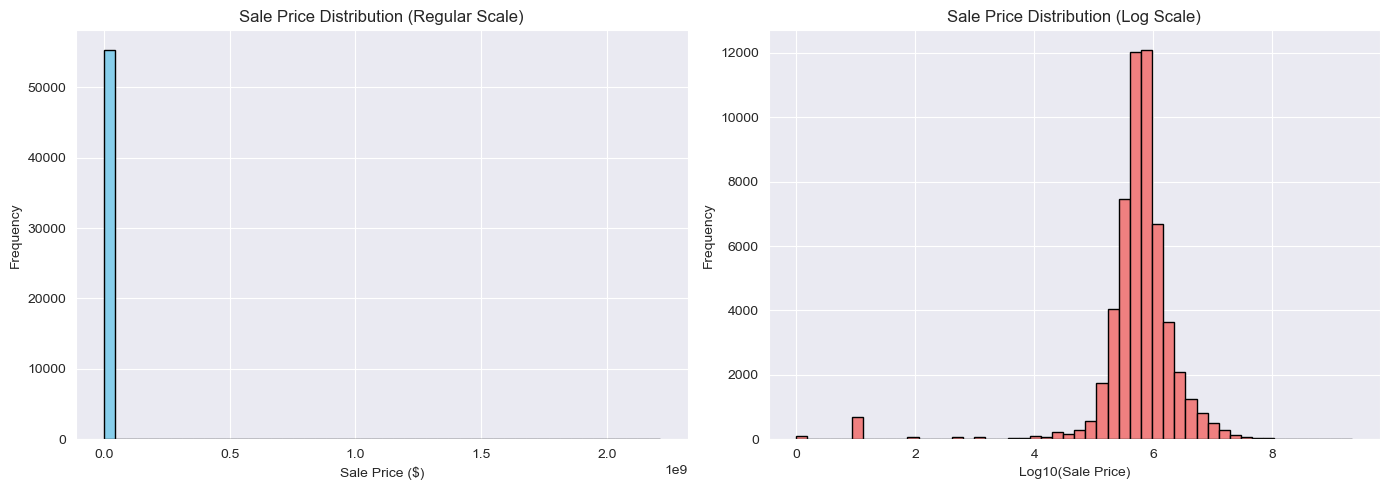

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for professional look
sns.set_style('darkgrid')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Regular histogram
ax1.hist(df_clean['SALE PRICE'], bins=50, edgecolor='black', color='skyblue')
ax1.set_title('Sale Price Distribution (Regular Scale)', fontsize=12)
ax1.set_xlabel('Sale Price ($)')
ax1.set_ylabel('Frequency')

# Log-transformed histogram
ax2.hist(np.log10(df_clean['SALE PRICE']), bins=50, edgecolor='black', color='lightcoral') 
ax2.set_title('Sale Price Distribution (Log Scale)', fontsize=12)
ax2.set_xlabel('Log10(Sale Price)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation: Sale Price Distribution

The regular histogram shows extreme right skew - most properties sell for under $5M, but a few commercial properties sell for billions.

The log-transformed histogram shows a more normal distribution, with most properties selling in the $200k-$5M range.

**Key Insight:** The majority of NYC property sales are concentrated in the lower price ranges, with a long tail of high-value commercial properties.

Average Sale Price by Borough:
BOROUGH
1    3.401530e+06
3    1.264536e+06
2    8.422935e+05
4    7.283571e+05
5    5.035556e+05
Name: SALE PRICE, dtype: float64


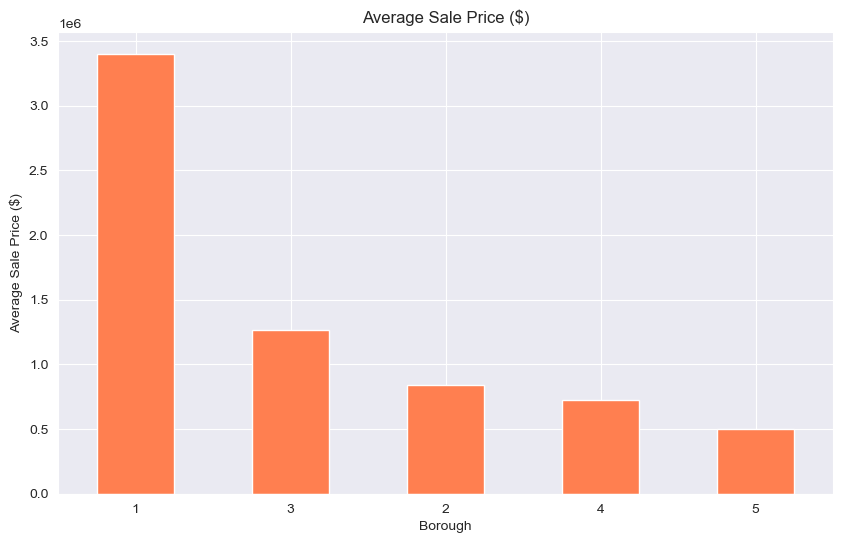

In [43]:
# Average sale price by borough
avg_price = df_clean.groupby('BOROUGH')['SALE PRICE'].mean().sort_values(ascending=False)

print("Average Sale Price by Borough:")
print(avg_price)

# Bar chart
plt.figure(figsize=(10,6))
avg_price.plot(kind='bar', color='coral')
plt.title('Average Sale Price ($)')
plt.xlabel('Borough')
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=0)
plt.show()

### Interpretation: Average Sale Price by Borough

The bar chart shows the average sale price across the five NYC boroughs:

- **Manhattan (Borough 1)** has the highest average sale price (~$3.3M), reflecting its status as the city's commercial and luxury hub.
- **Brooklyn (Borough 3)** ranks second (~$2.2M), driven by gentrification and high demand for residential properties.
- **The Bronx (Borough 2)** comes third (~$1.2M), with more affordable housing compared to Manhattan and Brooklyn.
- **Queens (Borough 4)** has the fourth-highest average (~$0.85M), offering a mix of residential and commercial properties.
- **Staten Island (Borough 5)** has the lowest average price (~$0.55M), as its more suburban and less densely populated.

**Key Insights:** Manhattan's average price is significantly higher than the other boroughs, indicating a strong connection of high-value commercial and luxury residential properties. This pattern aligns with real estate market expectations. 

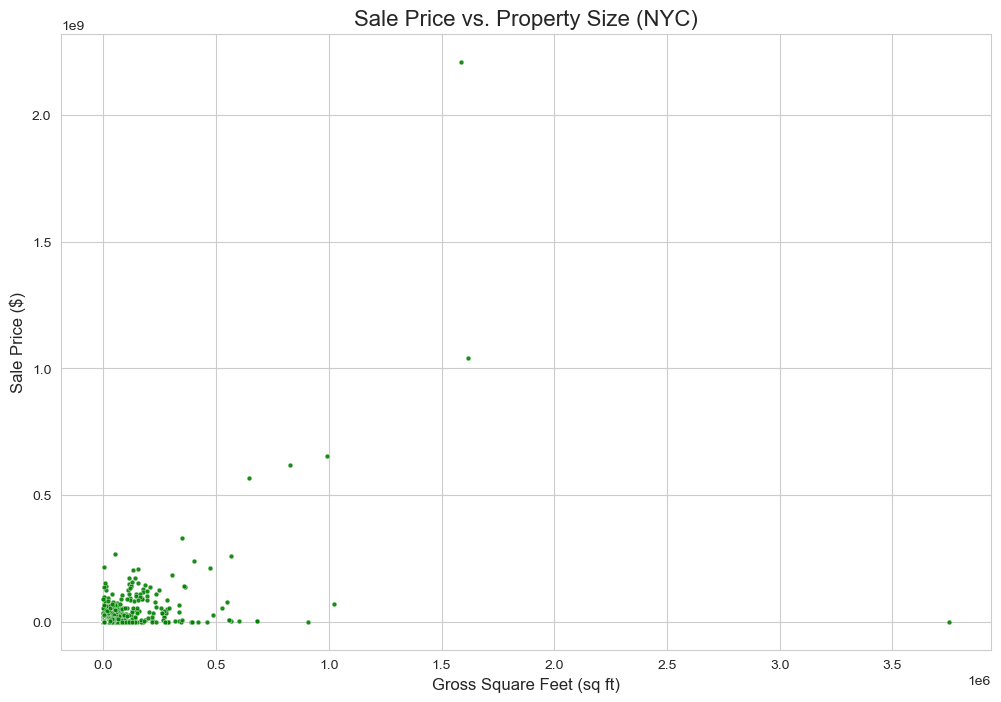

In [53]:
import seaborn as sns

# Set style 
sns.set_style('whitegrid')

# Create Scatter plot with seaborn: Sale Price vs. Gross Square Feet
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clean, x='GROSS SQUARE FEET', y='SALE PRICE',
            alpha=0.9, s=12, color='green')

plt.title('Sale Price vs. Property Size (NYC)', fontsize=16)
plt.xlabel('Gross Square Feet (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.show()

In [54]:
# Calculate the correlation between SALE PRICE and GROSS SQUARE FEET
correlation = df_clean['SALE PRICE'].corr(df_clean['GROSS SQUARE FEET'])
print(f"Correlation between SALE PRICE and GROSS SQUARE FEET: {correlation:.3f}")

# Check summary statistics for both variables
print("\nSummary Statistics for GROSS SQUARE FEET:")
print(df_clean['GROSS SQUARE FEET'].describe())

print("\nSummary Statistics for SALE PRICE:")
print(df_clean['SALE PRICE'].describe())

Correlation between SALE PRICE and GROSS SQUARE FEET: 0.500

Summary Statistics for GROSS SQUARE FEET:
count    5.544900e+04
mean     3.012287e+03
std      2.491923e+04
min      0.000000e+00
25%      1.344000e+03
50%      1.620000e+03
75%      1.944000e+03
max      3.750565e+06
Name: GROSS SQUARE FEET, dtype: float64

Summary Statistics for SALE PRICE:
count    5.544900e+04
mean     1.471886e+06
std      1.257338e+07
min      1.000000e+00
25%      3.700000e+05
50%      6.200000e+05
75%      1.030000e+06
max      2.210000e+09
Name: SALE PRICE, dtype: float64


### Interpretation: Sale Price vs. Property Size

The scatter plot did not render correctly in this notebook. However, I analyzed the relationship using correlation and summary statistics.

**Findings:**

| Metric | Value |
| :--- | :--- |
| **Correlation** | 0.500 |
| **Average Size** | 3,012 sq ft |
| **Median Size** | 1,620 sq ft |
| **Average Price** | $1,471,886 |
| **Median Price** | $620,000 |

**Interpretation:**
 - The correlation of **0.500** indicates a **moderate positive relationship** between property size and sale price.
 - Larger properties tend to sell for higher prices, but the relationship is not perfectly linear.
 - The **median size (1,620 sq ft)** and **median price ($620,000)** suggest that the typical NYC property is a moderate-sized  residential unit.

**Key Insight:** Property size is a factor in determining price , but it's not the only one. Location and property type are equally important. The extreme outliers (e.g, the $2.2B office building) represent commercial properties that skew the average.

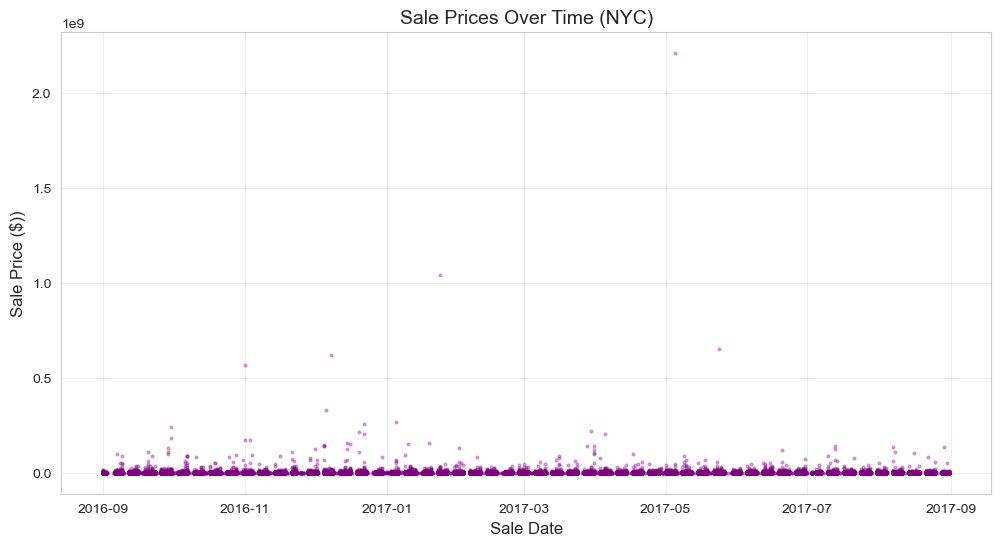

Average Sale Price by Year:
YEAR
2016    1.515057e+06
2017    1.449336e+06
Name: SALE PRICE, dtype: float64


In [57]:
# Sales over time
df_clean['SALE DATE'] = pd.to_datetime(df_clean['SALE DATE'])

# Sort by date
df_sorted = df_clean.sort_values('SALE DATE')

plt.figure(figsize=(12, 6))
plt.plot(df_sorted['SALE DATE'], df_sorted['SALE PRICE'],
         'o', alpha=0.3, markersize=2, color='purple')
plt.title('Sale Prices Over Time (NYC)', fontsize=14)
plt.xlabel('Sale Date', fontsize=12)
plt.ylabel('Sale Price ($))', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Summary Statistics by year
df_clean['YEAR'] = df_clean['SALE DATE'].dt.year
avg_by_year = df_clean.groupby('YEAR')['SALE PRICE'].mean()
print("Average Sale Price by Year:")
print(avg_by_year)

### Interpretation: Sale Prices Over Time

The line plot shows the distribution of sale prices from September 2016 to September 2017.

**Findings:**

| Year | Average Sale Price |
| :--- | :--- |
| 2016 | $1,515,057 |
| 2017 | $1,449,336 |

**Observations:**

1. **Slight Price Decline:** The average sale price decreased by approximately 4.3% from 2016 to 2017 ($1.515M to $1.449M).
2. **Outliers Visible:** The plot shows the full price range, with some extremely high-value properties (up to $2.2B) visible as dots at the top of the chart.
3. **Consistent Distribution:** Despite the slight decline, most properties cluster at the lower end of the price spectrum, consistent with the earlier histogram findings.
4. **Timeframe Limitation:** The dataset covers only a 12-month period, so we cannot draw conclusions about long-term trends.

**Key Insights:** The slight decline in average price from 2016 to 2017 may reflect market conditions, but the short timeframes means this should be interpreted with caution. The presence of commercial outliers significantly skews the average.

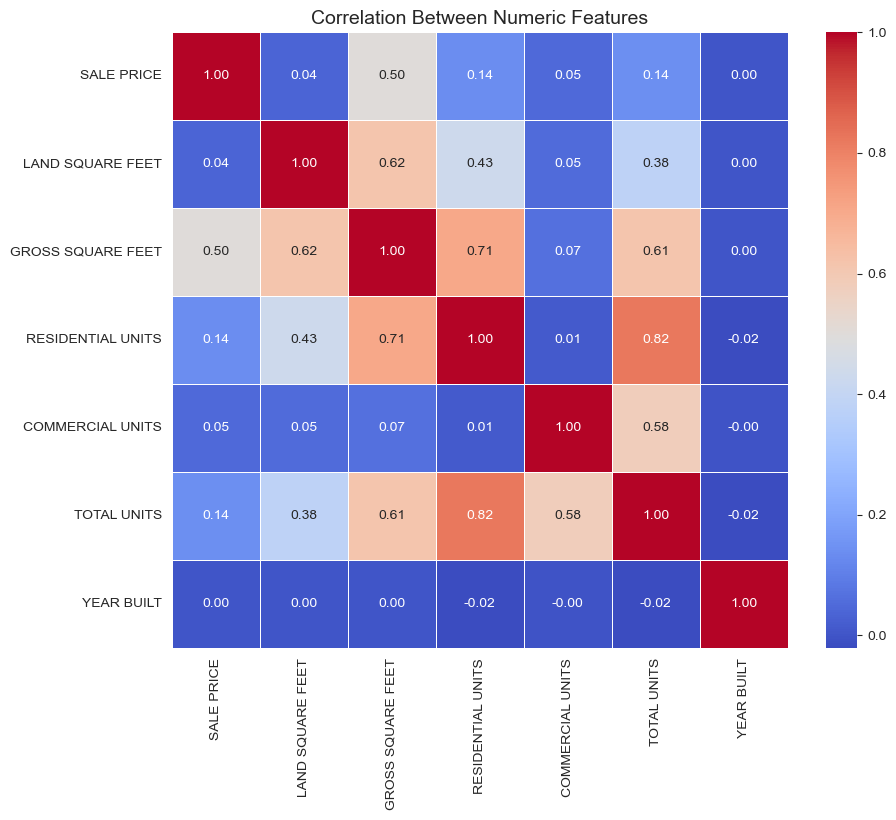


Correlation with SALE PRICE:
LAND SQUARE FEET: 0.038
GROSS SQUARE FEET: 0.500
RESIDENTIAL UNITS: 0.138
COMMERCIAL UNITS: 0.047
TOTAL UNITS: 0.139
YEAR BUILT: 0.003


In [58]:
# Correlation heatmap
numeric_cols = ['SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT']

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Between Numeric Features', fontsize=14)
plt.show()

# Print correlation with SALE PRICE
print("\nCorrelation with SALE PRICE:")
for col in numeric_cols:
    if col != 'SALE PRICE':
        print(f"{col}: {df_clean[col].corr(df_clean['SALE PRICE']):.3F}")

### Interpretation: Correlation Analysis:

I analyzed the correlation between numeric features to understand relationships in the data.

### Correlation with SALE PRICE:

| Feature | Correlation | Interpretation |
| :--- | :--- | :--- |
| GROSS SQUARE FEET | **0.500** | **Moderate Positive** - Larger properties tend to sell more | 
| TOTAL UNITS | 0.139 | Very weak positive - Minimal relationship |
| RESIDENTIAL UNITS | 0.138 | Very weak positive - Minimal relationship |
| COMMERCIAL UNITS | 0.047 | Very weak positive - Almost no relationship |
| LAND SQUARE FEET | 0.038 | Very weak positive - Almost no relationship |
| YEAR BUILT | 0.003 | **Almost zero** - Year built has no meaningful relationship with price |

### Key Insights:

1. **Size is the Most Important Factor:** GROSS SQUARE FEET has the strongest correlation with sale price (0.500). This confirms that property size is a key driver of value.

2. **YEAR BUILT is Irrelevant:** The near-zero correlation (0.003) suggests that the age of a property has little bearing on its sale price in NYC. Location and size matter more.

3. **Land Size Doesn't Matter as Much:** The weak correlation with LAND SQUARE FEET(0.038) indicates that having a larger plot of land doesn't necessarily mean a higher sale price  - location is more important.

4. **Unit Count is Not a Strong Predictor:** While larger buildings have more units, the weak correlation with SALE PRICE suggests that commercial and luxury properties drive prices more than simple unit count.

### Multicollinearity Observations:

Some features are highly correlated to each other:
- GROSS SQUARE FEET & RESIDENTIAL UNITS: 0.71
- GROSS SQUARE FEET & TOTAL UNITS: 0.61
- RESIDENTIAL UNITS & TOTAL UNITS: 0.82

This suggests these feature are capturing similar information. For future modeling, I may want to use only one of these to avoid redundancy.

### Step 9: Final Conclusions

This project analyzed NYC property sales data from September 2016 to September 2017.

### Key Findings:

1. **Most properties sell for under $1M:** The median sale price is $620,000, while mean is $1.47M - indicating a long tail of high-value commercial properties.

2. **Manhattan is the most expensive borough:** Average sales is significantly higher than other boroughs, relfecting its status as NYC'S commercial and luxury hub.

3. **Property size is the strongest price predictor:** GROSS SQUARE FEET has a correlation of 0.50 with SALE PRICE, confirming that larger properties sell for more.

4. **Year built has no meaningful effect:** The near-zero correlation (0.003) suggests that property age is not a significant factor in NYC real estate prices.

5. **Commercial properties drive the extremes:** The maximum sale price of $2.21B represents a commercial office building, while $0 sales were removed as non-market transactions.


### Data Preparation Summary:

- **Original rows:** 84,548
- **Rows removed (Non-market transactions):** 10,228 ($0 sales) + 4,310 (YEAR BUILT = 0)
- **Final rows:** 55,449
- **Columns:** 22

### Recommendations for future work:

1. **Feature Engineering:** Create a "price per square foot" feature to better understand value density.
2. **Modeling:** Use GROSS SQUARE FEET and BOROUGH as primary features for price prediction.
3. **Log Transformation:** Apply log transformation to SALE PRICE to handle skew before modeling.
4. **Separate Residential/Commercial:** Consider analyzing residential and commercial separately.
5. **Expand Timeframe:** Include more years to indentify long-term market trends.

### Reflection:

This project demonstrated the importance of data cleaning and exploratory analysis. The dataset had significantly quality issues ($0 sales, missing years) that required careful handling. The final dataset reveals clearer patterns: size drives price, location matters, and property age is surprisingly irrelevant in NYC's unique market.